<h2 style="text-align:center">TP: Problème de regression avec Keras</h2><br>
<h4>Durée: 2h</h4>

L'exercice est composé de plusieurs questions, faites-les dans l'ordre et faites attention à respecter le nom des variables.

L'objet de cet exercice consiste à comparer différents modèles de regression capable de prédire la consommation en essence d'une voiture à partir de certaines de ces caractéristiques. La variable cible est le MPG(https://en.wikipedia.org/wiki/Fuel_economy_in_automobiles#Units_of_measure) qui correspond au nombre de miles qu'on peut effectuer avec un baril d'essence. Ce notebook utilise le jeu de données classique Auto MPG(https://archive.ics.uci.edu/dataset/9/auto+mpg) qui contient des exemples d'automobiles de la fin des années 1970 et du début des années 1980 avec des données tels que : la cylindrée, la puissance, le poids.

<h4> Charger les packages et importer les données <h4>

* Importer les packages nécessaires et le jeu de données

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight', 'Acceleration', 'Model Year', 'Origin']

dataset = pd.read_csv('auto-mpg.data', names=column_names,
                          na_values='?', comment='\t',
                          sep=' ', skipinitialspace=True)

* Affichez les premières lignes du jeu de donneés

In [ ]:
dataset.head(5)


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


On utilise la fonction .head(5) pour afficher les 5 premières lignes du dataset pour vérifier que tous les champs sont présents

<h4> Nettoyer les donneés <h4>

* Est-ce que le dataset contient des donneés manquantes ? Si oui, traitez les en fonction de leur nombre et de leur position.


On utilise la fonction .isna().sum()  la première fonction .isna() permet de savoir qu’elle sont les valeurs nulles dans le dataset. La fonction somme nous permet de faire la somme des valeurs nulles par colonnes dans le dataset.


In [ ]:
# Insérer votre code ici
dataset.isna().sum()


,0
MPG,0
Cylinders,0
Displacement,0
Horsepower,6
Weight,0
Acceleration,0
Model Year,0
Origin,0


On remarque après exécution du code que 6 lignes dans le dataset ne possèdent pas la valeur Horsepower. Etant donné que c’est un toute petit partie du dataset on a donc décidé d’utiliser la fonction dropna() qui permet de supprimer les lignes qui ne sont pas complètes.
On vérifie alors qu’il n’y a plus de valeur nulles pour vérifier le bon fonctionnement.
Nous avons alors bien supprimé les valeurs null de notre dataset


In [ ]:
dataset = dataset.dropna().reset_index(drop=True)
dataset.isna().sum()

,0
MPG,0
Cylinders,0
Displacement,0
Horsepower,0
Weight,0
Acceleration,0
Model Year,0
Origin,0


* La colonne "Origin" est catégorielle, l'indice 1 correspond aux USA, l'indice 2 à l'Europe et l'indice 3 au Japon. Transformez cette variable en 3 variables binaires représentant l'origine du véhicule pour ces régions du monde.

Ensuite on cherche à scinder en 3 variables binaires pour séparer la colonne Origine grâce au préfixe origine. Origin_1 = USA (valeur binaire), Origin_2 = Europe (valeur binaire), Origin_3 = Japon (valeur binaire). Pour faire ça on utilise la fonction .get_dummies en paramètre on ajoute alors le dataset, la colonne à traiter origine et le préfix =’Origin.


In [ ]:
# Insérer votre code ici
dataset = pd.get_dummies(dataset, columns=['Origin'], prefix='Origin')
dataset = dataset.astype(float)
dataset.head()


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin_1,Origin_2,Origin_3
0,18.0,8.0,307.0,130.0,3504.0,12.0,70.0,1.0,0.0,0.0
1,15.0,8.0,350.0,165.0,3693.0,11.5,70.0,1.0,0.0,0.0
2,18.0,8.0,318.0,150.0,3436.0,11.0,70.0,1.0,0.0,0.0
3,16.0,8.0,304.0,150.0,3433.0,12.0,70.0,1.0,0.0,0.0
4,17.0,8.0,302.0,140.0,3449.0,10.5,70.0,1.0,0.0,0.0


<h4>Inspection et preprocessing des données</h4>

* En utilisant par exemple les fonctions **pairplot** ou **heatmap** de **seaborn**, étudiez les relations entre les variables de votre dataset. Que pouvez vous en déduire dans le cadre de notre problème de regression?

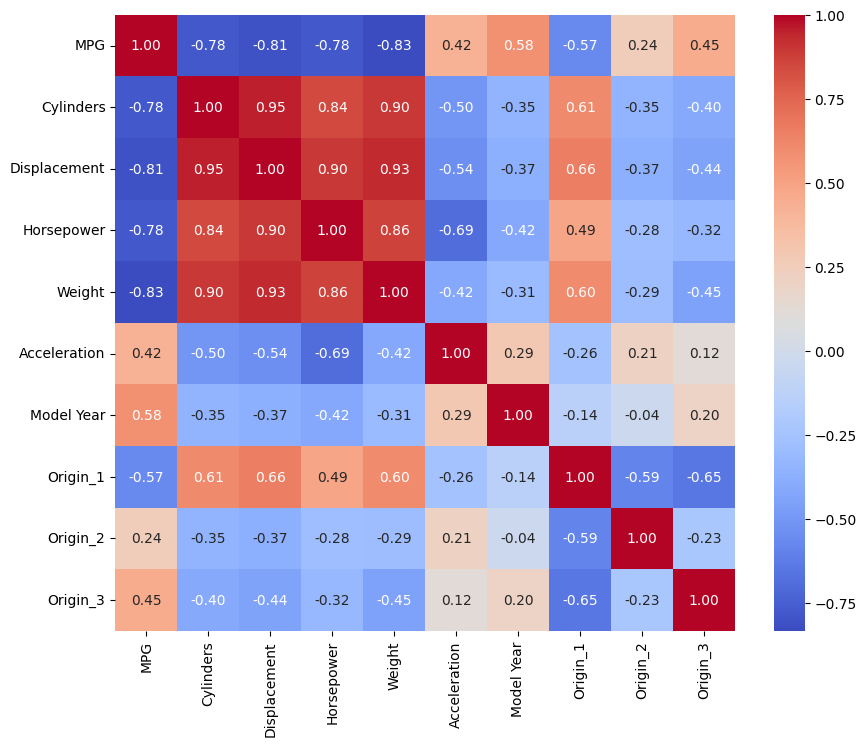

In [136]:
# Insérer votre code et réponse ici

plt.figure(figsize=(10, 8))
sns.heatmap(dataset.corr(), annot=True,cmap='coolwarm', fmt='.2f')
plt.show()



On cherche alors à étudier les relations entre les variables dans notre dataset. La variable cible MPG est fortement corrélée négativement avec Weight (- 83 %), Displacement (-81%), Horsepower (-78%) et Cylinders (-78%). On peut conclure que plus une voiture est lourde plus elle est puissante. Model Year est plutôt corrélée positivement avec MPG (58%), cela signifie alors que plus la voiture est récente moins elle consomme de carburant. Displacement et Cylinders sont fortement corrélé positivement (95%) ce qui signifie que plus une voiture et lourde ou puissante plus elle consomme du carburant. Grâce à se schémas on peut identifier beaucoup de variable pour prédire MPG grâce aux corrélations trouvées.  


* Etudiez la distribution des variables du dataset, pourquoi pensez-vous qu'une normalisation est ici nécessaire ?

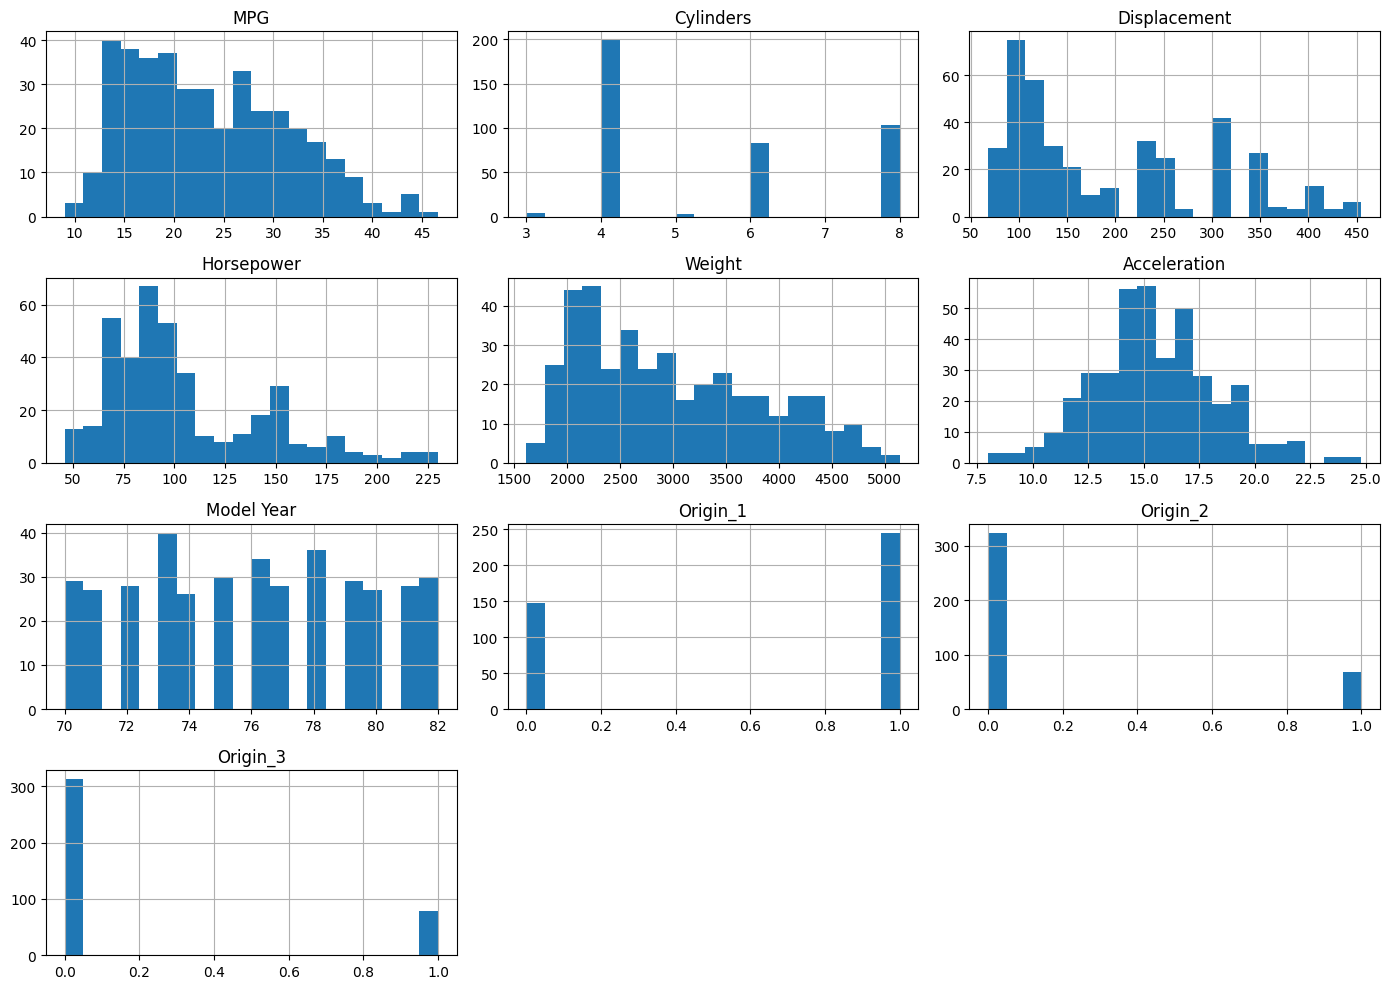

In [137]:
# Insérer votre code et réponse ici

dataset.hist(figsize=(14,10), bins=20)
plt.tight_layout()
plt.show()




Grace au graphique affichés on peut conclure qu’une normalisation des variables est nécessaire car les variables ne sont pas à la même échelle. Weith est de l’ordre de plusieurs milliers tandis que nous avons des variables binaires. Si nous ne normalisons pas le dataset les variables de grande amplitude domineraient l’entrainement des données et donc domineraient notre réseau de neurones.
La variable cible est la variable MPG (axe Y), tandis que tous les autres les variables explicatives (axe X)


* Séparez les variables explicatives dans un dataframe **X** et la variable cible dans **y**.

In [138]:

X=dataset.drop('MPG', axis=1)
y=dataset['MPG']
X.head(),y.head()



(   Cylinders  Displacement  Horsepower  Weight  Acceleration  Model Year  \
 0        8.0         307.0       130.0  3504.0          12.0        70.0   
 1        8.0         350.0       165.0  3693.0          11.5        70.0   
 2        8.0         318.0       150.0  3436.0          11.0        70.0   
 3        8.0         304.0       150.0  3433.0          12.0        70.0   
 4        8.0         302.0       140.0  3449.0          10.5        70.0   
 
    Origin_1  Origin_2  Origin_3  
 0       1.0       0.0       0.0  
 1       1.0       0.0       0.0  
 2       1.0       0.0       0.0  
 3       1.0       0.0       0.0  
 4       1.0       0.0       0.0  ,
 0    18.0
 1    15.0
 2    18.0
 3    16.0
 4    17.0
 Name: MPG, dtype: float64)

<h4>Préparer les données à l'entraînement<h4>

* Séparez le dataset en un jeu d'entraînement et un jeu de test. Appliquez ensuite une normalisation à votre dataset. C'est à vous de préciser le pourcentage pour les jeux d'entraînement et de test, ainsi que la méthode de normalisation. Vous devez également justifier la raison de votre choix.

In [140]:
# Insérer votre code et réponse ici
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


print("X train shape:", X_train.shape)
print("X test shape:", X_test.shape)
print("y train shape:", y_train.shape)
print("y test shape:", y_test.shape)


X train -> shape: (313, 9)
X test shape: (79, 9)
y train shape: (313,)
y test shape: (79,)


Nous avons fait le choix de séparer notre dataset de cette façon 80% de donnée d’entrainement et 20% de donnée de test. On a voulu avoir un gros pourcentage de donnée d’entrainement pour que se soit précis tout en gardant 20 pourcents pour tester notre modèle.
Pour normaliser notre dataset nous avons utiliser StandardScaler pour gérer au mieux les variables à échelle différente.


<h4>Premier modèle</h4>

Un neurone sans fonction d'activitation se comporte comme une modèle de regression linéaire, nous allons donc implémenter un modèle de regression linéaire en utilisant Keras.<br>
Créez un modèle nommé **linear_model** avec l'architecture suivante:<br>
* Une couche d'entrée "Dense", avec pour dimension le nombre de variables explicatives du modèle.<br>
* Une couche "Dense", avec 1 seul neurone, qui sera la couche de sortie.

In [141]:
# Insérer votre code ici

linear_model=tf.keras.Sequential([
    tf.keras.layers.Dense(X_train.shape[1], input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


* Affichez le résumé du modèle.

In [142]:
# Insérer votre code ici
linear_model.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 9)              │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100 (400.00 B)

 Trainable params: 100 (400.00 B)

 Non-trainable params: 0 (0.00 B)

* Compilez le modèle en choisissant une fonction de perte adaptée au problème, un optimiseur ainsi qu’un learning rate. Vous devez justifier vos choix en expliquant pourquoi ces paramètres sont appropriés pour ce type de modèle et de données.

In [143]:
# Insérer votre code et réponse ici

linear_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='mse',
    metrics=['mae']
)


Nous avons choisi la fonction de perte MSE car elle prend en compte d’avantages les grosses erreurs ce qui est adapté dans le cas d’une régression. L’utilisation de la fonction Adma nous permet d’avoir un optimiseur robuste et efficace pour converger rapidement.  Le modèle est plutôt simple et nous avons normalisé les données avant d’entrainer le modèle, nous avons donc décider de mettre 0,01 de learning rate.


* Entraînez le modèle sur **X_train** et **y_train** en utilisant la méthode **fit** avec les paramètres de votre choix.<br>
* Stockez l'historique d'entraînement dans une variable **linear_history**.

In [144]:
# Insérer votre code ici
linear_history = linear_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

print(linear_history.history)



{'loss': [611.2034301757812, 570.30615234375, 533.7324829101562, 499.0355529785156, 466.4639892578125, 432.50048828125, 391.28900146484375, 345.56927490234375, 297.4809265136719, 246.93992614746094, 197.7624053955078, 149.75975036621094, 108.97589111328125, 75.52192687988281, 51.2296257019043, 33.668128967285156, 22.915523529052734, 17.098201751708984, 14.241877555847168, 13.368995666503906, 12.90881633758545, 12.957437515258789, 12.708192825317383, 12.562872886657715, 12.577998161315918, 12.439900398254395, 12.379118919372559, 12.328906059265137, 12.171846389770508, 12.13780403137207, 12.004585266113281, 11.932948112487793, 11.916800498962402, 12.209981918334961, 12.082390785217285, 11.987114906311035, 11.96560287475586, 11.788426399230957, 11.713040351867676, 11.894904136657715, 11.698610305786133, 11.650016784667969, 11.649744987487793, 11.59165096282959, 11.662113189697266, 11.699913024902344, 11.561732292175293, 11.541336059570312, 11.572427749633789, 11.541576385498047, 11.643095

Validation_split  à 0,2 nous permet de faire une validation du modèle pendant l’entrainement
100 epochs permet d’avoir un apprentissage important mais à la fois suffisant
Le batch_size à 32 nous permet d’avoir de bonne performance tout en ayant un modèle stable
Et verbose = 0 nous permet de ne pas avoir l’affichage des logs durant l’entrainement du modèle


* Créez une fonction permettant d'afficher l'évolution de la loss stockée dans l'objet **history**.

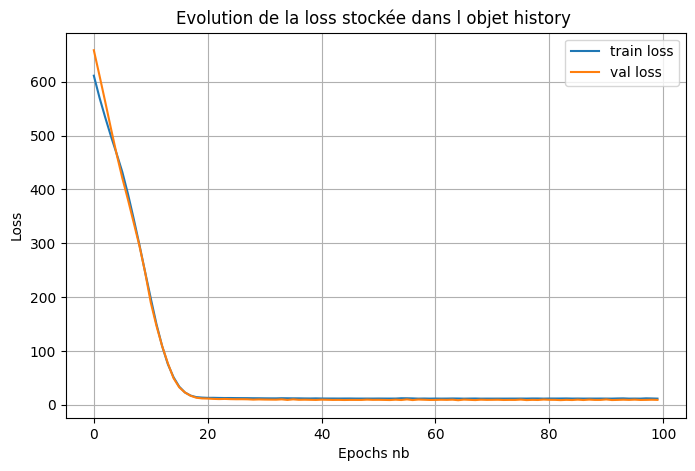

In [146]:
# Insérer votre code ici
def plot_loss(history):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='train loss')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='val loss')
    plt.xlabel('Epochs nb ')
    plt.ylabel('Loss')
    plt.title('Evolution de la loss stockée dans l objet history ')
    plt.legend()
    plt.grid(True)
    plt.show()


plot_loss(linear_history)

On affiche alors les courbe train loss et val loss qui se suivent et tendent vers 0 quand Epochs tend vers plus l’infini


* Stockez les résultats sur l'ensemble de test pour plus tard.

In [ ]:
# Insérer votre code ici
linear_test_results = linear_model.evaluate(X_test, y_test, verbose=0)
linear_test_results


[9.749683380126953, 2.2938125133514404]

<h4> Second modèle <h4>

Nous allons maintenant pouvoir implémenter un vrai modèle de Deep Learning et comparer les résultats.<br>

Créez un modèle nommé **dnn_model** avec l'architecture suivante:<br>

* Une couche d'entrée "Dense", avec pour dimension le nombre de variables explicatives du modèle.<br>

* **Deux** couches "Dense", avec 64 neurones chacune et une fonction d'activation à votre choix.(Justifiez votre choix)<br>

* Une couche de prédiction "Dense", avec 1 neurone.<br>

In [ ]:
# Insérer votre code ici
dnn_model = tf.keras.Sequential([
    tf.keras.layers.Dense(X_train.shape[1], input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Nous avons choisi la fonction d’activation ReLU car elle est simple efficace et limite la disparition de gradient. Nous avons fait le choix de mettre 2 couches de 64 neurones ce qui nous permet de trouver des relations non linéaires entre les différentes caractéristiques et le MPG.

* Affichez le résumé du modèle

In [ ]:
# Insérer votre code ici
dnn_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 9)              │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,955 (19.36 KB)

 Trainable params: 4,955 (19.36 KB)

 Non-trainable params: 0 (0.00 B)

* Compilez et entraîner le modèle de la même manière que le modèle précédent à la différence près que vous utiliserez une learning rate de **0,001** et que vous stockerez l'historique d'entraînement dans une variable **dnn_history**.

In [128]:
# Insérer votre code ici
dnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)


dnn_history = dnn_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=32,
    verbose=0
)
print(dnn_history.history)

{'loss': [591.40576171875, 560.6019897460938, 526.1898193359375, 484.0740966796875, 429.9662170410156, 363.1286926269531, 281.906982421875, 195.9087371826172, 122.99813079833984, 72.0184326171875, 54.861690521240234, 48.63287353515625, 41.0314826965332, 35.4737663269043, 32.27259063720703, 29.84073257446289, 27.933013916015625, 26.289718627929688, 24.888042449951172, 23.42770767211914, 22.190324783325195, 20.98626136779785, 19.989076614379883, 19.11424446105957, 18.29595947265625, 17.446277618408203, 16.832365036010742, 16.203176498413086, 15.679226875305176, 15.08029842376709, 14.646517753601074, 14.182426452636719, 13.794258117675781, 13.39419937133789, 13.089564323425293, 12.642556190490723, 12.4114408493042, 12.155149459838867, 11.827523231506348, 11.574346542358398, 11.338171005249023, 11.052679061889648, 10.840027809143066, 10.629620552062988, 10.377662658691406, 10.19543743133545, 10.048676490783691, 9.92333698272705, 9.71953010559082, 9.668421745300293, 9.40672492980957, 9.4411

* Visualizez l'évolution de la loss de ce modèle.

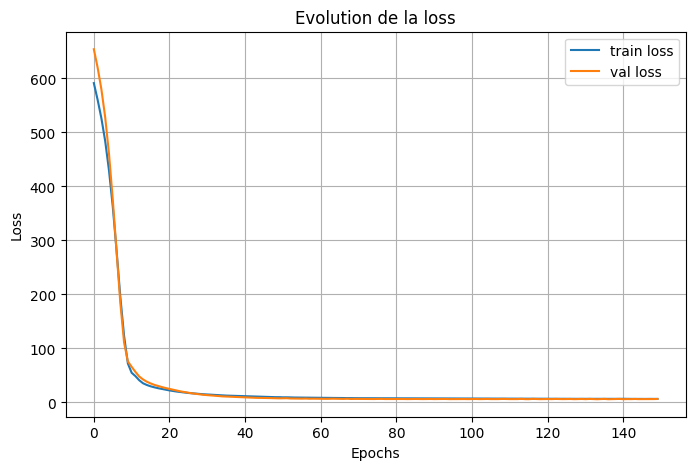

In [129]:
# Insérer votre code ici
plot_loss(dnn_history)

* Récupèrez les prédictions.

In [130]:
# Insérer votre code ici
dnn_predictions = dnn_model.predict(X_test).flatten()
dnn_predictions[:10]

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


array([25.480486, 24.511501, 34.446087, 25.290726, 28.226265, 28.589844,
       13.474108, 29.584465, 18.559793, 31.187166], dtype=float32)

<h4>Performance</h4>

* Comparez les performances du modèle linéaire et du réseau de neurone.

In [147]:
# Insérer votre code ici
linear_predictions = linear_model.predict(X_test).flatten()


linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)


dnn_mae = mean_absolute_error(y_test, dnn_predictions)
dnn_rmse = np.sqrt(mean_squared_error(y_test, dnn_predictions))
dnn_r2 = r2_score(y_test, dnn_predictions)


results = pd.DataFrame({
    'Model': ['linear model', 'DNN Model'],
    'MAE': [linear_mae, dnn_mae],
    'RMSE': [linear_rmse, dnn_rmse],
    'R2': [linear_r2, dnn_r2]
})


results


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


,Model,MAE,RMSE,R2
0,linear model,2.455176,3.235259,0.79493
1,DNN Model,1.630292,2.302184,0.89616


* Comment interprétez vous ces résultats ?

Le modèle DNN obtient de meilleures performances que le modèle linéaire. Les indicateurs Mae et RMSE sont plus faibles donc les prédictions sont plus proches de la réalité. L’indicateur R2 est plus élevé pour le DNN ce qui indique que le modèle comprend mieux la variance de donnée. La relation entre les variables et MPG n’est pas linéaire donc le réseau de neurone est plus adapté.


<h4> Prédictions</h4>

 * Affichez les écarts entre les prédictions du modèle de deep learning avec les vraies valeurs de MPG

In [149]:
# Insérer votre code ici
comparaison = pd.DataFrame({
    'valeur reelle': y_test.values,
    'prediction DNN': dnn_predictions,
    'erreure': y_test.values - dnn_predictions
})


comparaison.head(20)

,valeur reelle,prediction DNN,erreure
0,26.0,25.480486,0.519514
1,21.6,24.511501,-2.911501
2,36.1,34.446087,1.653913
3,26.0,25.290726,0.709274
4,27.0,28.226265,-1.226265
5,28.0,28.589844,-0.589844
6,13.0,13.474108,-0.474108
7,26.0,29.584465,-3.584465
8,19.0,18.559793,0.440207
9,29.0,31.187166,-2.187166


* Affichez la distribution des erreurs.

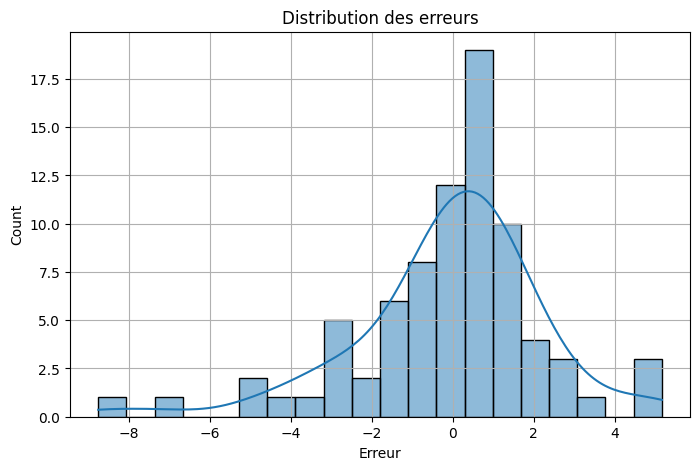

In [134]:
# Insérer votre code ici

errors = y_test.values - dnn_predictions


plt.figure(figsize=(8, 5))
sns.histplot(errors, bins=20, kde=True)
plt.xlabel('nb Erreurs')
plt.title('Histogramme de distribution des erreurs')
plt.grid(True)
plt.show()

La distribution des erreurs est centrée sur 0 et 1 ce qui signifie que le modèle n’a pas de biais ou un biais faible, la plupart des erreurs sont faibles et proches de la valeur réelle. Certaines valeurs sont plus difficiles à prédire comme on peut le constater sur la valeur -3 qui posséde 5 répétitions mais cela reste acceptable.
